# 04 모델 구조 기반 Confidence Classification / Binary Classification

이 노트북은 `confidence 분류기 5-17실험/bsd10k_confidence_mlp_colab.ipynb`의 기존 입력 구성인 `audio embedding + text embedding + class one-hot`을 사용하되, 모델 구조는 `04_similarity_feature_mlp_confidence.ipynb`와 동일하게 맞춘다.

사용 모델 구조:

```python
Linear(input_dim, 32)
ReLU()
Dropout(0.2)
Linear(32, output_dim)
```

실험 대상:

- 5-class confidence classification: confidence 1~5
- Binary high-confidence classification: confidence 1/2/3 vs 4/5

In [1]:
from pathlib import Path
import json
import random
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    mean_absolute_error,
    mean_squared_error,
    precision_recall_fscore_support,
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from torch.utils.data import DataLoader, TensorDataset
from tqdm.auto import tqdm

warnings.filterwarnings('ignore')

SEED = 42
BATCH_SIZE = 128
EPOCHS = 120
LR = 1e-3
WEIGHT_DECAY = 1e-4
VAL_SIZE = 0.2
HIDDEN_DIM = 32
DROPOUT = 0.2
NUM_WORKERS = 0

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

def seed_everything(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

seed_everything(SEED)
print('DEVICE:', DEVICE)

DEVICE: cuda


## 경로 설정

In [2]:
try:
    HERE = Path(__file__).resolve().parent
except NameError:
    HERE = Path.cwd().resolve()

if HERE.name == 'confidence 분류기 5-17실험':
    PROJECT_ROOT = HERE.parent
else:
    PROJECT_ROOT = HERE

METADATA_CSV = PROJECT_ROOT / 'data' / 'metadata' / 'BSD10k_metadata.csv'
AUDIO_EMB_DIR = PROJECT_ROOT / 'data' / 'features' / 'clap_audio_embeddings'
TEXT_EMB_DIR = PROJECT_ROOT / 'data' / 'features' / 'clap_text_embeddings'

OUTPUT_DIR = PROJECT_ROOT / 'outputs' / 'confidence_mlp_04_structure_outputs'
PLOT_DIR = OUTPUT_DIR / 'plots'
REPORT_DIR = OUTPUT_DIR / 'reports'
PRED_DIR = OUTPUT_DIR / 'predictions'
MODEL_DIR = OUTPUT_DIR / 'models'
for path in [OUTPUT_DIR, PLOT_DIR, REPORT_DIR, PRED_DIR, MODEL_DIR]:
    path.mkdir(parents=True, exist_ok=True)

print('PROJECT_ROOT:', PROJECT_ROOT)
print('METADATA_CSV:', METADATA_CSV, METADATA_CSV.exists())
print('AUDIO_EMB_DIR:', AUDIO_EMB_DIR, AUDIO_EMB_DIR.exists())
print('TEXT_EMB_DIR:', TEXT_EMB_DIR, TEXT_EMB_DIR.exists())
print('OUTPUT_DIR:', OUTPUT_DIR)

PROJECT_ROOT: C:\Users\solok\Desktop\Dcase baseline
METADATA_CSV: C:\Users\solok\Desktop\Dcase baseline\data\metadata\BSD10k_metadata.csv True
AUDIO_EMB_DIR: C:\Users\solok\Desktop\Dcase baseline\data\features\clap_audio_embeddings True
TEXT_EMB_DIR: C:\Users\solok\Desktop\Dcase baseline\data\features\clap_text_embeddings True
OUTPUT_DIR: C:\Users\solok\Desktop\Dcase baseline\outputs\confidence_mlp_04_structure_outputs


## 데이터 로딩

In [3]:
meta = pd.read_csv(METADATA_CSV)
required_cols = ['sound_id', 'class', 'confidence']
missing_cols = [c for c in required_cols if c not in meta.columns]
if missing_cols:
    raise ValueError(f'Missing metadata columns: {missing_cols}')

audio_paths = {p.stem: p for p in AUDIO_EMB_DIR.glob('*.npy')}
text_paths = {p.stem: p for p in TEXT_EMB_DIR.glob('*.npy')}

rows = []
audio_list = []
text_list = []
missing_audio = 0
missing_text = 0
invalid_confidence = 0

for _, row in tqdm(meta.iterrows(), total=len(meta)):
    sound_id = str(row['sound_id'])
    audio_path = audio_paths.get(sound_id)
    text_path = text_paths.get(sound_id)
    if audio_path is None:
        missing_audio += 1
        continue
    if text_path is None:
        missing_text += 1
        continue
    try:
        confidence = int(row['confidence'])
    except Exception:
        invalid_confidence += 1
        continue
    if confidence not in [1, 2, 3, 4, 5]:
        invalid_confidence += 1
        continue

    rows.append({
        'sound_id': sound_id,
        'class': row['class'],
        'confidence': confidence,
    })
    audio_list.append(np.load(audio_path).reshape(-1).astype(np.float32))
    text_list.append(np.load(text_path).reshape(-1).astype(np.float32))

df = pd.DataFrame(rows)
audio_emb = np.stack(audio_list).astype(np.float32)
text_emb = np.stack(text_list).astype(np.float32)

print('rows:', len(df))
print('missing_audio:', missing_audio)
print('missing_text:', missing_text)
print('invalid_confidence:', invalid_confidence)
print('audio_emb:', audio_emb.shape)
print('text_emb:', text_emb.shape)
display(df.head())
display(df['confidence'].value_counts().sort_index().rename('count').to_frame())

  0%|          | 0/10956 [00:00<?, ?it/s]

rows: 10956
missing_audio: 0
missing_text: 0
invalid_confidence: 0
audio_emb: (10956, 512)
text_emb: (10956, 512)


,sound_id,class,confidence
0,185755,fx-o,4
1,358405,is-w,5
2,358760,is-w,4
3,432206,fx-o,4
4,80630,sp-s,5


,count
confidence,
1,106
2,749
3,3280
4,6045
5,776


## Feature 생성: audio + text + class one-hot

In [4]:
class_encoder = LabelEncoder()
class_ids = class_encoder.fit_transform(df['class'].values)
num_classes = len(class_encoder.classes_)

class_onehot = np.eye(num_classes, dtype=np.float32)[class_ids]
if class_onehot.shape[1] < 23:
    padded = np.zeros((class_onehot.shape[0], 23), dtype=np.float32)
    padded[:, :class_onehot.shape[1]] = class_onehot
    class_onehot = padded
elif class_onehot.shape[1] > 23:
    raise ValueError(f'class_onehot dimension exceeds 23: {class_onehot.shape[1]}')

X_full = np.concatenate([audio_emb, text_emb, class_onehot], axis=1).astype(np.float32)
y_5class = df['confidence'].to_numpy(dtype=np.int64) - 1
y_binary = (df['confidence'].to_numpy(dtype=np.int64) >= 4).astype(np.int64)

df['class_idx'] = class_ids
df['binary_confidence'] = y_binary

df.to_csv(REPORT_DIR / 'dataset_index.csv', index=False, encoding='utf-8-sig')
np.save(REPORT_DIR / 'X_audio_text_class.npy', X_full)
(REPORT_DIR / 'class_mapping.json').write_text(
    json.dumps({int(i): str(cls) for i, cls in enumerate(class_encoder.classes_)}, indent=2, ensure_ascii=False),
    encoding='utf-8',
)

print('X_full:', X_full.shape)
print('class_onehot:', class_onehot.shape)
print('5-class target:', np.bincount(y_5class))
print('binary target:', np.bincount(y_binary))
for idx, cls in enumerate(class_encoder.classes_):
    print(idx, '->', cls)

X_full: (10956, 1047)
class_onehot: (10956, 23)
5-class target: [ 106  749 3280 6045  776]
binary target: [4135 6821]
0 -> fx-a
1 -> fx-el
2 -> fx-ex
3 -> fx-h
4 -> fx-m
5 -> fx-n
6 -> fx-o
7 -> fx-v
8 -> is-e
9 -> is-k
10 -> is-p
11 -> is-s
12 -> is-w
13 -> m-m
14 -> m-si
15 -> m-sp
16 -> sp-c
17 -> sp-p
18 -> sp-s
19 -> ss-i
20 -> ss-n
21 -> ss-s
22 -> ss-u


## Train/validation split + scaling

In [5]:
idx = np.arange(len(df))
train_idx, val_idx = train_test_split(
    idx,
    test_size=VAL_SIZE,
    random_state=SEED,
    stratify=y_5class,
)

split_df = pd.DataFrame({'sound_id': df['sound_id'], 'split': 'train'})
split_df.loc[val_idx, 'split'] = 'val'
split_df.to_csv(REPORT_DIR / 'splits.csv', index=False, encoding='utf-8-sig')

scaler = StandardScaler()
X_train = scaler.fit_transform(X_full[train_idx]).astype(np.float32)
X_val = scaler.transform(X_full[val_idx]).astype(np.float32)

print('train/val:', len(train_idx), len(val_idx))
display(pd.crosstab(split_df['split'], df['confidence'], rownames=['split'], colnames=['confidence']))

train/val: 8764 2192


confidence,1,2,3,4,5
split,,,,,
train,85,599,2624,4835,621
val,21,150,656,1210,155


## 04와 동일한 모델 구조

In [6]:
class OneLayerMLP(nn.Module):
    def __init__(self, input_dim, output_dim, hidden_dim=32, dropout=0.2):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, output_dim),
        )

    def forward(self, x):
        return self.net(x)


def make_loader(X_arr, y_arr, batch_size=BATCH_SIZE, shuffle=False):
    ds = TensorDataset(torch.from_numpy(X_arr), torch.from_numpy(y_arr.astype(np.int64)))
    return DataLoader(ds, batch_size=batch_size, shuffle=shuffle, num_workers=NUM_WORKERS, pin_memory=True)


def compute_metrics(y_true, y_pred, labels_for_mae=None):
    p_macro, r_macro, f1_macro, _ = precision_recall_fscore_support(y_true, y_pred, average='macro', zero_division=0)
    p_weighted, r_weighted, f1_weighted, _ = precision_recall_fscore_support(y_true, y_pred, average='weighted', zero_division=0)
    if labels_for_mae == 'one_based':
        mae = mean_absolute_error(y_true + 1, y_pred + 1)
        mse = mean_squared_error(y_true + 1, y_pred + 1)
    else:
        mae = mean_absolute_error(y_true, y_pred)
        mse = mean_squared_error(y_true, y_pred)
    return {
        'accuracy': accuracy_score(y_true, y_pred),
        'macro_precision': p_macro,
        'macro_recall': r_macro,
        'macro_f1': f1_macro,
        'weighted_precision': p_weighted,
        'weighted_recall': r_weighted,
        'weighted_f1': f1_weighted,
        'mae': mae,
        'mse': mse,
    }


def train_mlp(task_name, X_train, y_train, X_val, y_val, output_dim, labels_for_mae=None):
    seed_everything(SEED)
    model = OneLayerMLP(
        input_dim=X_train.shape[1],
        output_dim=output_dim,
        hidden_dim=HIDDEN_DIM,
        dropout=DROPOUT,
    ).to(DEVICE)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

    train_loader = make_loader(X_train, y_train, shuffle=True)
    val_loader = make_loader(X_val, y_val, shuffle=False)

    history = []
    best_state = None
    best_epoch = None
    best_val_loss = float('inf')

    for epoch in range(1, EPOCHS + 1):
        model.train()
        train_loss = 0.0
        for xb, yb in train_loader:
            xb = xb.to(DEVICE)
            yb = yb.to(DEVICE)
            optimizer.zero_grad()
            logits = model(xb)
            loss = criterion(logits, yb)
            loss.backward()
            optimizer.step()
            train_loss += loss.item() * len(yb)
        train_loss /= len(train_loader.dataset)

        model.eval()
        val_loss = 0.0
        all_true = []
        all_pred = []
        with torch.no_grad():
            for xb, yb in val_loader:
                xb = xb.to(DEVICE)
                yb = yb.to(DEVICE)
                logits = model(xb)
                loss = criterion(logits, yb)
                pred = logits.argmax(dim=1)
                val_loss += loss.item() * len(yb)
                all_true.append(yb.cpu().numpy())
                all_pred.append(pred.cpu().numpy())
        val_loss /= len(val_loader.dataset)
        y_true_epoch = np.concatenate(all_true)
        y_pred_epoch = np.concatenate(all_pred)
        epoch_metrics = compute_metrics(y_true_epoch, y_pred_epoch, labels_for_mae=labels_for_mae)
        history.append({'epoch': epoch, 'train_loss': train_loss, 'val_loss': val_loss, **epoch_metrics})

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_epoch = epoch
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

        print(
            f"{task_name} epoch {epoch:03d}/{EPOCHS} | "
            f"train_loss={train_loss:.4f} | val_loss={val_loss:.4f} | "
            f"acc={epoch_metrics['accuracy']:.4f} | mae={epoch_metrics['mae']:.4f} | f1={epoch_metrics['macro_f1']:.4f}"
        )

    model.load_state_dict(best_state)
    history_df = pd.DataFrame(history)
    history_df.to_csv(REPORT_DIR / f'{task_name}_history.csv', index=False, encoding='utf-8-sig')

    fig, ax = plt.subplots(figsize=(7, 4.5))
    ax.plot(history_df['epoch'], history_df['train_loss'], label='train loss')
    ax.plot(history_df['epoch'], history_df['val_loss'], label='validation loss')
    ax.axvline(best_epoch, color='gray', linestyle='--', linewidth=1, label=f'best epoch {best_epoch}')
    ax.set_title(f'{task_name} train/validation loss')
    ax.set_xlabel('epoch')
    ax.set_ylabel('cross entropy loss')
    ax.legend()
    ax.grid(axis='y', alpha=0.3)
    fig.tight_layout()
    fig.savefig(PLOT_DIR / f'{task_name}_loss_curve.png', dpi=180)
    plt.show()

    print(f'{task_name} best_epoch:', best_epoch, 'best_val_loss:', round(best_val_loss, 6))
    return model, history_df, {'best_epoch': best_epoch, 'best_val_loss': best_val_loss}


def predict(model, X_arr):
    loader = DataLoader(torch.from_numpy(X_arr), batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
    model.eval()
    preds = []
    probs = []
    with torch.no_grad():
        for xb in loader:
            xb = xb.to(DEVICE)
            logits = model(xb)
            prob = torch.softmax(logits, dim=1).cpu().numpy()
            pred = prob.argmax(axis=1)
            probs.append(prob)
            preds.append(pred)
    return np.concatenate(preds), np.concatenate(probs)

## 5-class confidence classification

confidence_5class_04_structure_mlp epoch 001/120 | train_loss=1.2380 | val_loss=0.9860 | acc=0.5698 | mae=0.4991 | f1=0.2327
confidence_5class_04_structure_mlp epoch 002/120 | train_loss=0.9918 | val_loss=0.9608 | acc=0.5798 | mae=0.4726 | f1=0.2812
confidence_5class_04_structure_mlp epoch 003/120 | train_loss=0.9444 | val_loss=0.9513 | acc=0.5776 | mae=0.4804 | f1=0.2828
confidence_5class_04_structure_mlp epoch 004/120 | train_loss=0.9159 | val_loss=0.9552 | acc=0.5821 | mae=0.4786 | f1=0.3039
confidence_5class_04_structure_mlp epoch 005/120 | train_loss=0.8951 | val_loss=0.9595 | acc=0.5844 | mae=0.4685 | f1=0.3037
confidence_5class_04_structure_mlp epoch 006/120 | train_loss=0.8794 | val_loss=0.9604 | acc=0.5780 | mae=0.4776 | f1=0.2956
confidence_5class_04_structure_mlp epoch 007/120 | train_loss=0.8672 | val_loss=0.9642 | acc=0.5817 | mae=0.4699 | f1=0.3014
confidence_5class_04_structure_mlp epoch 008/120 | train_loss=0.8551 | val_loss=0.9642 | acc=0.5785 | mae=0.4763 | f1=0.3024


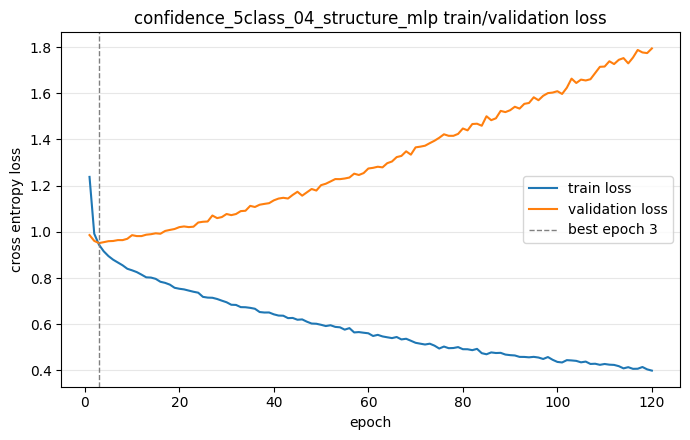

confidence_5class_04_structure_mlp best_epoch: 3 best_val_loss: 0.951298
              precision    recall  f1-score   support

confidence_1     0.0000    0.0000    0.0000        21
confidence_2     0.5333    0.0533    0.0970       150
confidence_3     0.4753    0.3674    0.4144       656
confidence_4     0.6100    0.8248    0.7013      1210
confidence_5     0.5588    0.1226    0.2011       155

    accuracy                         0.5776      2192
   macro avg     0.4355    0.2736    0.2828      2192
weighted avg     0.5550    0.5776    0.5320      2192



,accuracy,macro_precision,macro_recall,macro_f1,weighted_precision,weighted_recall,weighted_f1,mae,mse,task,best_epoch,best_val_loss
0,0.5776,0.4355,0.2736,0.2828,0.555,0.5776,0.532,0.4804,0.6072,confidence_5class_04_structure_mlp,3,0.9513


,pred_1,pred_2,pred_3,pred_4,pred_5
true_1,0,0,9,12,0
true_2,0,8,60,82,0
true_3,0,1,241,413,1
true_4,0,6,192,998,14
true_5,0,0,5,131,19


In [7]:
y5_train = y_5class[train_idx]
y5_val = y_5class[val_idx]

model_5class, history_5class, best_5class = train_mlp(
    task_name='confidence_5class_04_structure_mlp',
    X_train=X_train,
    y_train=y5_train,
    X_val=X_val,
    y_val=y5_val,
    output_dim=5,
    labels_for_mae='one_based',
)

pred5, prob5 = predict(model_5class, X_val)
true5 = y5_val
metrics_5class = compute_metrics(true5, pred5, labels_for_mae='one_based')
metrics_5class.update({
    'task': 'confidence_5class_04_structure_mlp',
    'best_epoch': best_5class['best_epoch'],
    'best_val_loss': best_5class['best_val_loss'],
})
metrics_5class_df = pd.DataFrame([metrics_5class])

true5_label = true5 + 1
pred5_label = pred5 + 1
labels_5 = [1, 2, 3, 4, 5]
cm_5class = confusion_matrix(true5_label, pred5_label, labels=labels_5)
cm_5class_df = pd.DataFrame(cm_5class, index=[f'true_{x}' for x in labels_5], columns=[f'pred_{x}' for x in labels_5])
cm_5class_norm = cm_5class.astype(np.float32) / np.maximum(cm_5class.sum(axis=1, keepdims=True), 1)

report_5class_text = classification_report(
    true5_label,
    pred5_label,
    labels=labels_5,
    target_names=[f'confidence_{x}' for x in labels_5],
    digits=4,
    zero_division=0,
)
report_5class_dict = classification_report(
    true5_label,
    pred5_label,
    labels=labels_5,
    target_names=[f'confidence_{x}' for x in labels_5],
    output_dict=True,
    zero_division=0,
)

metrics_5class_df.to_csv(REPORT_DIR / 'confidence_5class_04_structure_metrics.csv', index=False, encoding='utf-8-sig')
cm_5class_df.to_csv(REPORT_DIR / 'confidence_5class_04_structure_confusion_counts.csv', encoding='utf-8-sig')
pd.DataFrame(cm_5class_norm, index=cm_5class_df.index, columns=cm_5class_df.columns).to_csv(REPORT_DIR / 'confidence_5class_04_structure_confusion_row_normalized.csv', encoding='utf-8-sig')
(REPORT_DIR / 'confidence_5class_04_structure_classification_report.txt').write_text(report_5class_text, encoding='utf-8')
pd.DataFrame(report_5class_dict).T.to_csv(REPORT_DIR / 'confidence_5class_04_structure_classification_report.csv', encoding='utf-8-sig')

pred_5class_df = pd.DataFrame({
    'sound_id': df.loc[val_idx, 'sound_id'].values,
    'true_confidence': true5_label,
    'pred_confidence': pred5_label,
    'correct': true5_label == pred5_label,
    'pred_confidence_prob': prob5.max(axis=1),
})
for i in range(5):
    pred_5class_df[f'prob_confidence_{i + 1}'] = prob5[:, i]
pred_5class_df.to_csv(PRED_DIR / 'confidence_5class_04_structure_val_predictions.csv', index=False, encoding='utf-8-sig')

torch.save({
    'model_state_dict': {k: v.detach().cpu() for k, v in model_5class.state_dict().items()},
    'feature_description': 'audio_embedding_512 + text_embedding_512 + class_one_hot_23',
    'model_description': 'Linear(input_dim, 32) -> ReLU -> Dropout(0.2) -> Linear(32, 5)',
    'input_dim': int(X_full.shape[1]),
    'output_dim': 5,
    'hidden_dim': HIDDEN_DIM,
    'dropout': DROPOUT,
    'labels': labels_5,
    'class_mapping': {int(i): str(cls) for i, cls in enumerate(class_encoder.classes_)},
    'metrics': metrics_5class,
}, MODEL_DIR / 'confidence_5class_04_structure_mlp.pt')

print(report_5class_text)
display(metrics_5class_df.round(4))
display(cm_5class_df)

### 5-class normalized confusion matrix

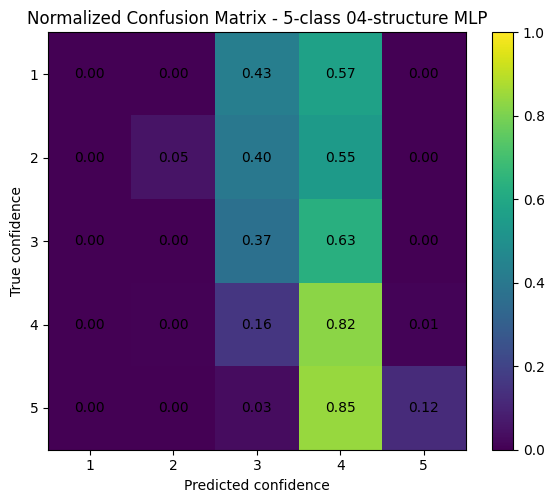

In [8]:
plt.figure(figsize=(6, 5))
plt.imshow(cm_5class_norm, vmin=0, vmax=1)
plt.title('Normalized Confusion Matrix - 5-class 04-structure MLP')
plt.xlabel('Predicted confidence')
plt.ylabel('True confidence')
plt.xticks(range(5), labels_5)
plt.yticks(range(5), labels_5)
for i in range(cm_5class_norm.shape[0]):
    for j in range(cm_5class_norm.shape[1]):
        plt.text(j, i, f'{cm_5class_norm[i, j]:.2f}', ha='center', va='center')
plt.colorbar()
plt.tight_layout()
plt.savefig(PLOT_DIR / 'confidence_5class_04_structure_confusion_row_normalized.png', dpi=180)
plt.show()

## Binary classification: confidence 1/2/3 vs 4/5

confidence_binary_123_vs_45_04_structure_mlp epoch 001/120 | train_loss=0.6028 | val_loss=0.5755 | acc=0.6829 | mae=0.3171 | f1=0.6442
confidence_binary_123_vs_45_04_structure_mlp epoch 002/120 | train_loss=0.5566 | val_loss=0.5787 | acc=0.6811 | mae=0.3189 | f1=0.6427
confidence_binary_123_vs_45_04_structure_mlp epoch 003/120 | train_loss=0.5445 | val_loss=0.5689 | acc=0.6870 | mae=0.3130 | f1=0.6539
confidence_binary_123_vs_45_04_structure_mlp epoch 004/120 | train_loss=0.5321 | val_loss=0.5746 | acc=0.6984 | mae=0.3016 | f1=0.6697
confidence_binary_123_vs_45_04_structure_mlp epoch 005/120 | train_loss=0.5183 | val_loss=0.5787 | acc=0.6875 | mae=0.3125 | f1=0.6585
confidence_binary_123_vs_45_04_structure_mlp epoch 006/120 | train_loss=0.5112 | val_loss=0.5788 | acc=0.6880 | mae=0.3120 | f1=0.6577
confidence_binary_123_vs_45_04_structure_mlp epoch 007/120 | train_loss=0.5008 | val_loss=0.5924 | acc=0.6902 | mae=0.3098 | f1=0.6613
confidence_binary_123_vs_45_04_structure_mlp epoch 008/

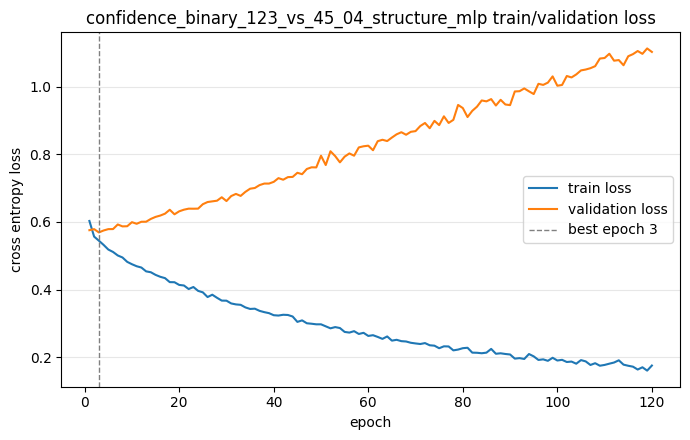

confidence_binary_123_vs_45_04_structure_mlp best_epoch: 3 best_val_loss: 0.568911
                precision    recall  f1-score   support

confidence_123     0.6026    0.5006    0.5469       827
 confidence_45     0.7256    0.8000    0.7610      1365

      accuracy                         0.6870      2192
     macro avg     0.6641    0.6503    0.6539      2192
  weighted avg     0.6792    0.6870    0.6802      2192



,accuracy,macro_precision,macro_recall,macro_f1,weighted_precision,weighted_recall,weighted_f1,mae,mse,task,best_epoch,best_val_loss
0,0.687,0.6641,0.6503,0.6539,0.6792,0.687,0.6802,0.313,0.313,confidence_binary_123_vs_45_04_structure_mlp,3,0.5689


,pred_123,pred_45
true_123,414,413
true_45,273,1092


In [9]:
yb_train = y_binary[train_idx]
yb_val = y_binary[val_idx]

model_binary, history_binary, best_binary = train_mlp(
    task_name='confidence_binary_123_vs_45_04_structure_mlp',
    X_train=X_train,
    y_train=yb_train,
    X_val=X_val,
    y_val=yb_val,
    output_dim=2,
)

pred_binary, prob_binary = predict(model_binary, X_val)
true_binary = yb_val
metrics_binary = compute_metrics(true_binary, pred_binary)
metrics_binary.update({
    'task': 'confidence_binary_123_vs_45_04_structure_mlp',
    'best_epoch': best_binary['best_epoch'],
    'best_val_loss': best_binary['best_val_loss'],
})
metrics_binary_df = pd.DataFrame([metrics_binary])

labels_binary = [0, 1]
cm_binary = confusion_matrix(true_binary, pred_binary, labels=labels_binary)
cm_binary_df = pd.DataFrame(cm_binary, index=['true_123', 'true_45'], columns=['pred_123', 'pred_45'])
cm_binary_norm = cm_binary.astype(np.float32) / np.maximum(cm_binary.sum(axis=1, keepdims=True), 1)

report_binary_text = classification_report(
    true_binary,
    pred_binary,
    labels=labels_binary,
    target_names=['confidence_123', 'confidence_45'],
    digits=4,
    zero_division=0,
)
report_binary_dict = classification_report(
    true_binary,
    pred_binary,
    labels=labels_binary,
    target_names=['confidence_123', 'confidence_45'],
    output_dict=True,
    zero_division=0,
)

metrics_binary_df.to_csv(REPORT_DIR / 'confidence_binary_123_vs_45_04_structure_metrics.csv', index=False, encoding='utf-8-sig')
cm_binary_df.to_csv(REPORT_DIR / 'confidence_binary_123_vs_45_04_structure_confusion_counts.csv', encoding='utf-8-sig')
pd.DataFrame(cm_binary_norm, index=cm_binary_df.index, columns=cm_binary_df.columns).to_csv(REPORT_DIR / 'confidence_binary_123_vs_45_04_structure_confusion_row_normalized.csv', encoding='utf-8-sig')
(REPORT_DIR / 'confidence_binary_123_vs_45_04_structure_classification_report.txt').write_text(report_binary_text, encoding='utf-8')
pd.DataFrame(report_binary_dict).T.to_csv(REPORT_DIR / 'confidence_binary_123_vs_45_04_structure_classification_report.csv', encoding='utf-8-sig')

pred_binary_df = pd.DataFrame({
    'sound_id': df.loc[val_idx, 'sound_id'].values,
    'true_binary_confidence': true_binary,
    'pred_binary_confidence': pred_binary,
    'correct': true_binary == pred_binary,
    'prob_123': prob_binary[:, 0],
    'prob_45': prob_binary[:, 1],
})
pred_binary_df.to_csv(PRED_DIR / 'confidence_binary_123_vs_45_04_structure_val_predictions.csv', index=False, encoding='utf-8-sig')

torch.save({
    'model_state_dict': {k: v.detach().cpu() for k, v in model_binary.state_dict().items()},
    'feature_description': 'audio_embedding_512 + text_embedding_512 + class_one_hot_23',
    'model_description': 'Linear(input_dim, 32) -> ReLU -> Dropout(0.2) -> Linear(32, 2)',
    'input_dim': int(X_full.shape[1]),
    'output_dim': 2,
    'hidden_dim': HIDDEN_DIM,
    'dropout': DROPOUT,
    'labels': {'0': 'confidence_123', '1': 'confidence_45'},
    'class_mapping': {int(i): str(cls) for i, cls in enumerate(class_encoder.classes_)},
    'metrics': metrics_binary,
}, MODEL_DIR / 'confidence_binary_123_vs_45_04_structure_mlp.pt')

print(report_binary_text)
display(metrics_binary_df.round(4))
display(cm_binary_df)

### Binary normalized confusion matrix

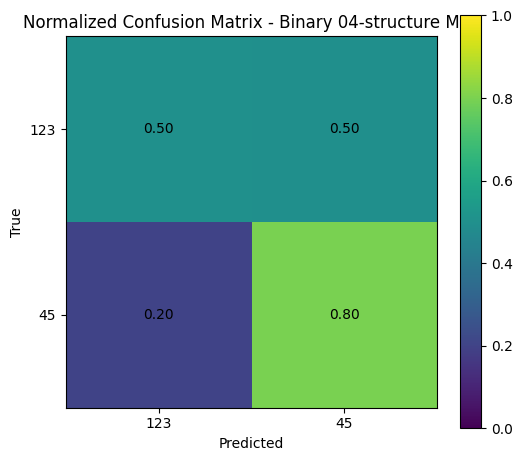

In [10]:
plt.figure(figsize=(5.5, 4.8))
plt.imshow(cm_binary_norm, vmin=0, vmax=1)
plt.title('Normalized Confusion Matrix - Binary 04-structure MLP')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.xticks(range(2), ['123', '45'])
plt.yticks(range(2), ['123', '45'])
for i in range(cm_binary_norm.shape[0]):
    for j in range(cm_binary_norm.shape[1]):
        plt.text(j, i, f'{cm_binary_norm[i, j]:.2f}', ha='center', va='center')
plt.colorbar()
plt.tight_layout()
plt.savefig(PLOT_DIR / 'confidence_binary_123_vs_45_04_structure_confusion_row_normalized.png', dpi=180)
plt.show()

## 통합 결과 저장

In [12]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import confusion_matrix, classification_report

def plot_confusion_matrix(cm, x_labels, y_labels, title, save_path=None, normalize=True):
    cm = np.asarray(cm)
    if normalize:
        cm_plot = cm.astype(np.float32) / np.maximum(cm.sum(axis=1, keepdims=True), 1)
        fmt = ".2f"
        vmin, vmax = 0, 1
    else:
        cm_plot = cm
        fmt = "d"
        vmin, vmax = None, None

    plt.figure(figsize=(6, 5))
    plt.imshow(cm_plot, vmin=vmin, vmax=vmax)
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.xticks(range(len(x_labels)), x_labels)
    plt.yticks(range(len(y_labels)), y_labels)

    for i in range(cm_plot.shape[0]):
        for j in range(cm_plot.shape[1]):
            value = cm_plot[i, j]
            text = f"{value:{fmt}}" if normalize else f"{int(value)}"
            plt.text(j, i, text, ha="center", va="center")

    plt.colorbar()
    plt.tight_layout()

    if save_path is not None:
        plt.savefig(save_path, dpi=180)

    plt.show()

,pred_1,pred_2,pred_3,pred_4,pred_5
true_1,8,60,82,0,0
true_2,1,241,413,1,0
true_3,6,192,998,14,0
true_4,0,5,131,19,0
true_5,0,0,0,0,0


              precision    recall  f1-score   support

confidence_1     0.5333    0.0533    0.0970       150
confidence_2     0.4753    0.3674    0.4144       656
confidence_3     0.6100    0.8248    0.7013      1210
confidence_4     0.5588    0.1226    0.2011       155
confidence_5     0.0000    0.0000    0.0000         0

   micro avg     0.5776    0.5831    0.5803      2171
   macro avg     0.4355    0.2736    0.2828      2171
weighted avg     0.5604    0.5831    0.5372      2171



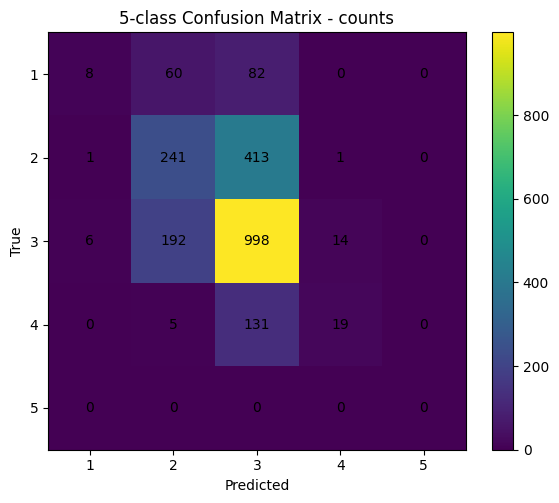

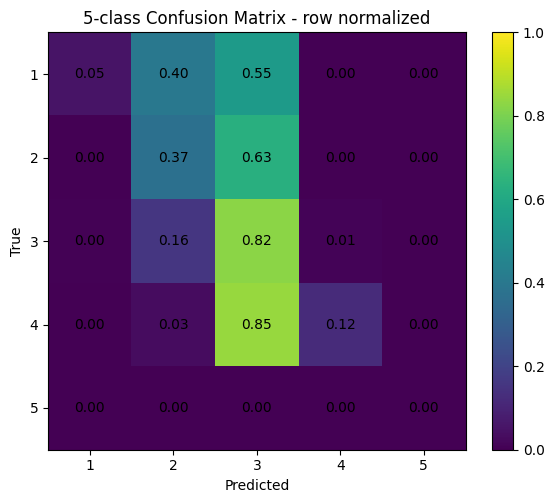

,pred_123,pred_45
true_123,414,413
true_45,273,1092


                precision    recall  f1-score   support

confidence_123     0.6026    0.5006    0.5469       827
 confidence_45     0.7256    0.8000    0.7610      1365

      accuracy                         0.6870      2192
     macro avg     0.6641    0.6503    0.6539      2192
  weighted avg     0.6792    0.6870    0.6802      2192



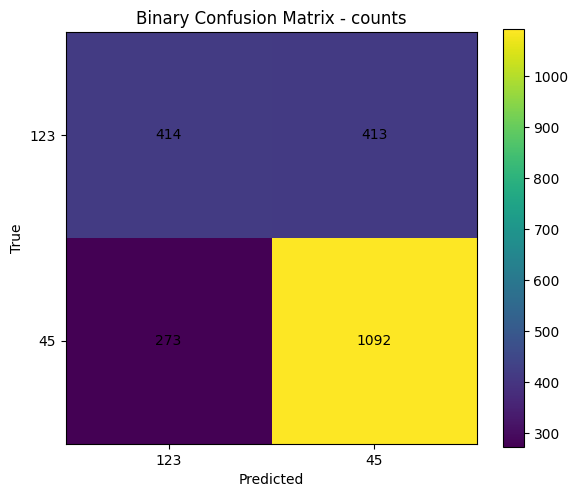

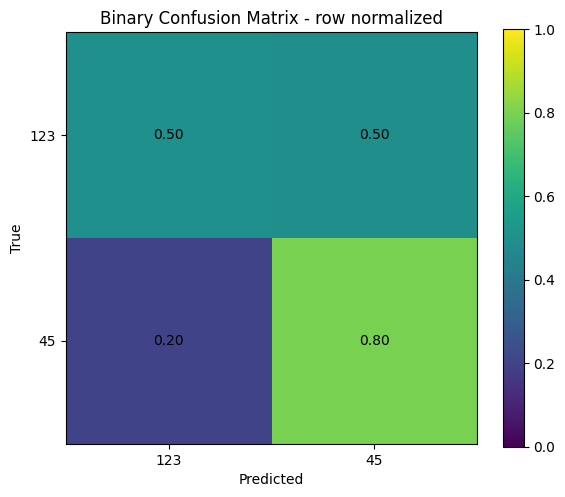

In [13]:
# 5-class confidence confusion matrix
labels_5 = [1, 2, 3, 4, 5]

cm_5class = confusion_matrix(true5, pred5, labels=labels_5)
cm_5class_df = pd.DataFrame(
    cm_5class,
    index=[f"true_{x}" for x in labels_5],
    columns=[f"pred_{x}" for x in labels_5],
)

display(cm_5class_df)

print(classification_report(
    true5,
    pred5,
    labels=labels_5,
    target_names=[f"confidence_{x}" for x in labels_5],
    digits=4,
    zero_division=0,
))

plot_confusion_matrix(
    cm_5class,
    x_labels=labels_5,
    y_labels=labels_5,
    title="5-class Confusion Matrix - counts",
    normalize=False,
)

plot_confusion_matrix(
    cm_5class,
    x_labels=labels_5,
    y_labels=labels_5,
    title="5-class Confusion Matrix - row normalized",
    save_path=PLOT_DIR / "confidence_5class_confusion_matrix_row_normalized.png",
    normalize=True,
)

# Binary confidence confusion matrix
labels_binary = [0, 1]
binary_names = ["123", "45"]

cm_binary = confusion_matrix(true_binary, pred_binary, labels=labels_binary)
cm_binary_df = pd.DataFrame(
    cm_binary,
    index=["true_123", "true_45"],
    columns=["pred_123", "pred_45"],
)

display(cm_binary_df)

print(classification_report(
    true_binary,
    pred_binary,
    labels=labels_binary,
    target_names=["confidence_123", "confidence_45"],
    digits=4,
    zero_division=0,
))

plot_confusion_matrix(
    cm_binary,
    x_labels=binary_names,
    y_labels=binary_names,
    title="Binary Confusion Matrix - counts",
    normalize=False,
)

plot_confusion_matrix(
    cm_binary,
    x_labels=binary_names,
    y_labels=binary_names,
    title="Binary Confusion Matrix - row normalized",
    save_path=PLOT_DIR / "confidence_binary_123_vs_45_confusion_matrix_row_normalized.png",
    normalize=True,
)

In [11]:
all_metrics = pd.concat([metrics_5class_df, metrics_binary_df], ignore_index=True)
all_metrics.to_csv(REPORT_DIR / 'all_04_structure_mlp_metrics.csv', index=False, encoding='utf-8-sig')

summary = {
    'feature_description': 'audio_embedding_512 + text_embedding_512 + class_one_hot_23',
    'model_structure': 'Linear(input_dim, 32) -> ReLU -> Dropout(0.2) -> Linear(32, output_dim)',
    'input_dim': int(X_full.shape[1]),
    'audio_embedding_dim': int(audio_emb.shape[1]),
    'text_embedding_dim': int(text_emb.shape[1]),
    'class_onehot_dim': int(class_onehot.shape[1]),
    'hidden_dim': HIDDEN_DIM,
    'dropout': DROPOUT,
    'epochs': EPOCHS,
    'batch_size': BATCH_SIZE,
    'lr': LR,
    'weight_decay': WEIGHT_DECAY,
    'val_size': VAL_SIZE,
    'metrics': json.loads(all_metrics.to_json(orient='records')),
}
(REPORT_DIR / 'summary.json').write_text(json.dumps(summary, indent=2, ensure_ascii=False), encoding='utf-8')

report_lines = []
report_lines.append('# 04-Structure MLP Confidence Report')
report_lines.append('')
report_lines.append('## Feature')
report_lines.append('- audio_embedding_512 + text_embedding_512 + class_one_hot_23')
report_lines.append(f'- total input dim: {X_full.shape[1]}')
report_lines.append('')
report_lines.append('## Model')
report_lines.append('- Linear(input_dim, 32) -> ReLU -> Dropout(0.2) -> Linear(32, output_dim)')
report_lines.append('')
report_lines.append('## Metrics')
report_lines.append('```text')
report_lines.append(all_metrics.round(4).to_string(index=False))
report_lines.append('```')
report_lines.append('')
report_lines.append('## 5-class classification report')
report_lines.append('```text')
report_lines.append(report_5class_text)
report_lines.append('```')
report_lines.append('')
report_lines.append('## Binary classification report')
report_lines.append('```text')
report_lines.append(report_binary_text)
report_lines.append('```')
(REPORT_DIR / '04_structure_mlp_report.md').write_text('\n'.join(report_lines), encoding='utf-8')

display(all_metrics.round(4))
print('saved:', OUTPUT_DIR)

,accuracy,macro_precision,macro_recall,macro_f1,weighted_precision,weighted_recall,weighted_f1,mae,mse,task,best_epoch,best_val_loss
0,0.5776,0.4355,0.2736,0.2828,0.5550,0.5776,0.5320,0.4804,0.6072,confidence_5class_04_structure_mlp,3,0.9513
1,0.6870,0.6641,0.6503,0.6539,0.6792,0.6870,0.6802,0.3130,0.3130,confidence_binary_123_vs_45_04_structure_mlp,3,0.5689


saved: C:\Users\solok\Desktop\Dcase baseline\outputs\confidence_mlp_04_structure_outputs
